# Упражнение 2.2

## Пилообразный сигнал

In [ ]:
from thinkdsp import Sinusoid
import numpy as np

class SawtoothSignal(Sinusoid):
    def evaluate(self, ts):
        """Evaluate the signal at the given times.

        ts: float or array of floats
        """
        return 2 * (ts * self.freq - np.floor(ts * self.freq + 0.5))

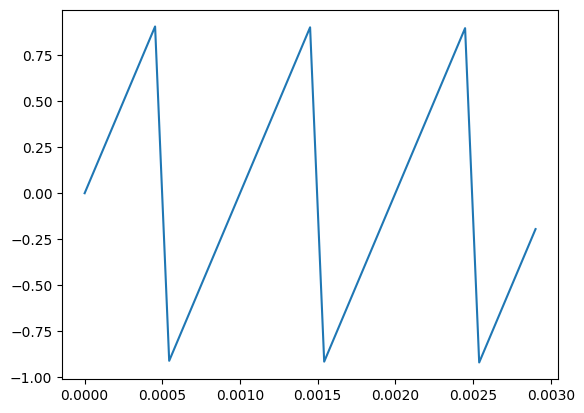

In [32]:
signal = SawtoothSignal(freq=1000)
signal.plot()

## Спектр

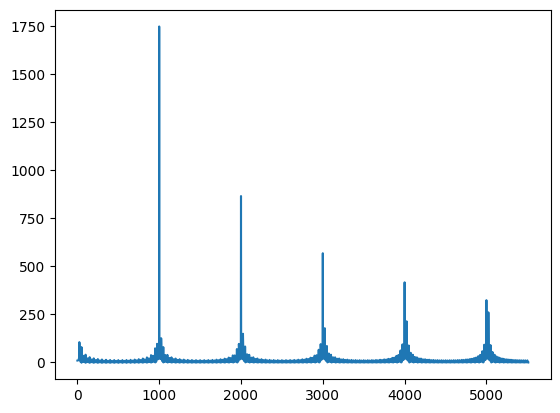

In [33]:
wave = signal.make_wave(duration=0.5)
spectrum = wave.make_spectrum()
spectrum.plot()

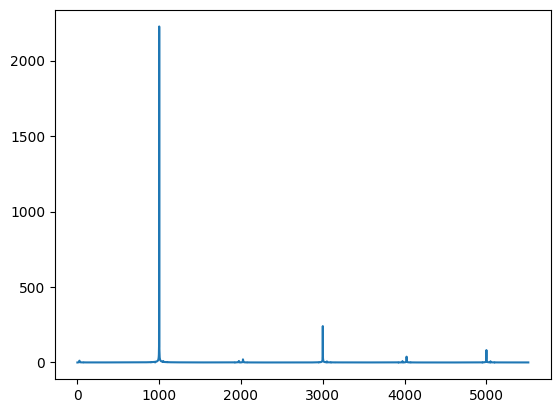

In [34]:
from thinkdsp import TriangleSignal

wave = TriangleSignal(freq=1000).make_wave(duration=0.5)
spectrum = wave.make_spectrum()
spectrum.plot()

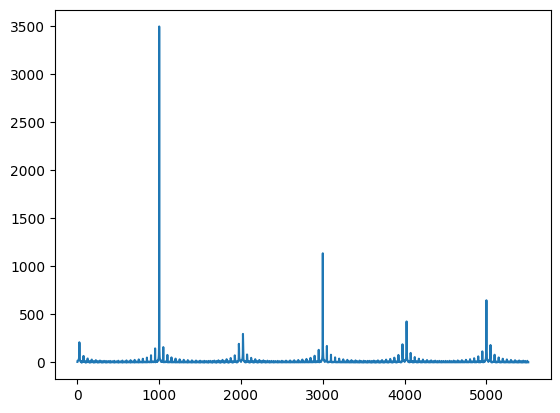

In [36]:
from thinkdsp import SquareSignal

wave = SquareSignal(freq=1000).make_wave(duration=0.5)
spectrum = wave.make_spectrum()
spectrum.plot()

У пилообразного сигнала есть все гармоники, у двух других только нечетные. У треугольного вдобавок быстрее падает амплитуда.

# Упражнение 2.3

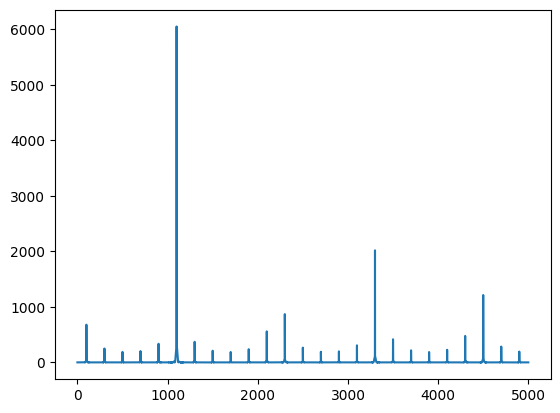

In [51]:
signal = SquareSignal(freq=1100)
wave = signal.make_wave(framerate=10000, duration=1)
wave.apodize()
spectrum = wave.make_spectrum()
spectrum.plot()

In [52]:
wave.make_audio()

Слышны паразитные низкие компоненты низких частот, создается ощущение грязного звучания.

# Упражнение 2.4

In [78]:
from thinkdsp import TriangleSignal

sig = TriangleSignal(freq=440)
wave = sig.make_wave(duration=0.01, framerate=10000)
print(wave.ys[:4])

[0.96388977 0.78967374 0.61545771 0.44124169]


In [79]:
spec = wave.make_spectrum()
h0 = spec.hs[0]
print("h0 =", h0)
print("амплитуда =", abs(h0))
print("фаза =", h0.imag)

h0 = (3.375077994860476e-14+0j)
амплитуда = 3.375077994860476e-14
фаза = 0.0


In [80]:
spec.hs[0] = 100
wave2 = spec.make_wave()


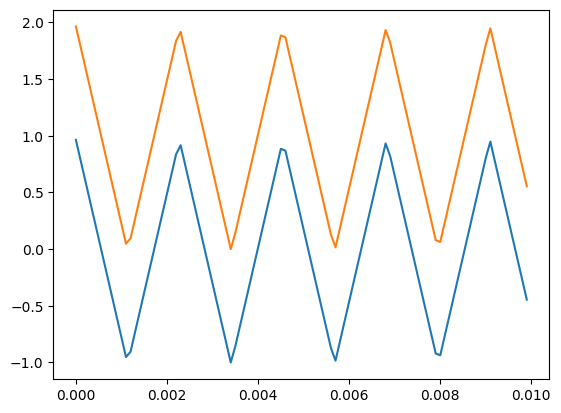

In [81]:
wave.plot()
wave2.plot()

Сигнал сдвинулся на +1 и почти не изменился. Такой сдвиг мог произойти из-за длительности сигнала

# Упражнение 2.5

In [ ]:
from thinkdsp import Spectrum

def normalize(spec: Spectrum):
    spec.hs[0] = 0
    for i, freq in enumerate(spec.fs):
        if freq == 0:
            continue
        spec.hs[i] /= freq

## Прямоугольный сигнал

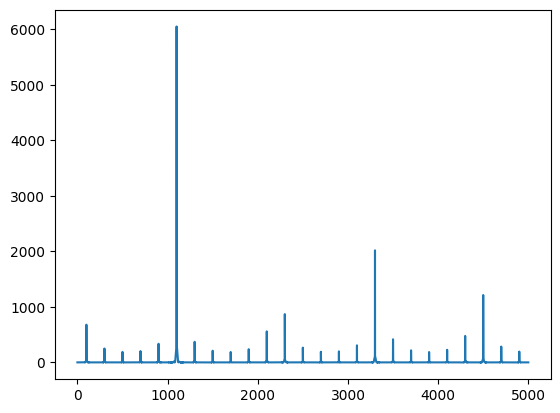

In [ ]:
from thinkdsp import SquareSignal

signal = SquareSignal(freq=1100)
wave = signal.make_wave(framerate=10000, duration=1)
wave.apodize()
spectrum = wave.make_spectrum()
spectrum.plot()
wave.make_audio() # old

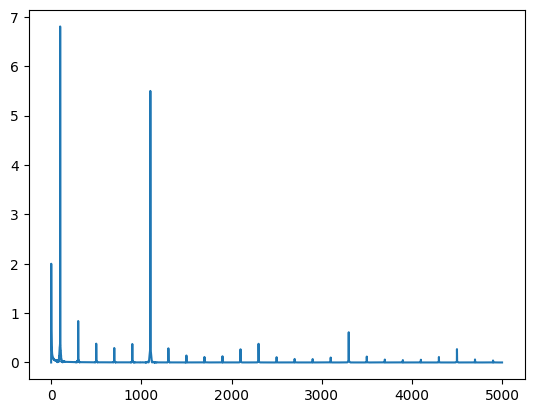

In [92]:
normalize(spectrum)
spectrum.plot()
wave = spectrum.make_wave() # new
wave.make_audio()

## Треугольный сигнал

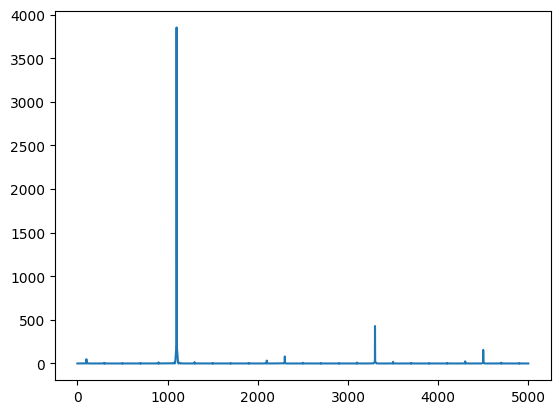

In [93]:
from thinkdsp import TriangleSignal

signal = TriangleSignal(freq=1100)
wave = signal.make_wave(framerate=10000, duration=1)
wave.apodize()
spectrum = wave.make_spectrum()
spectrum.plot()
wave.make_audio() # old

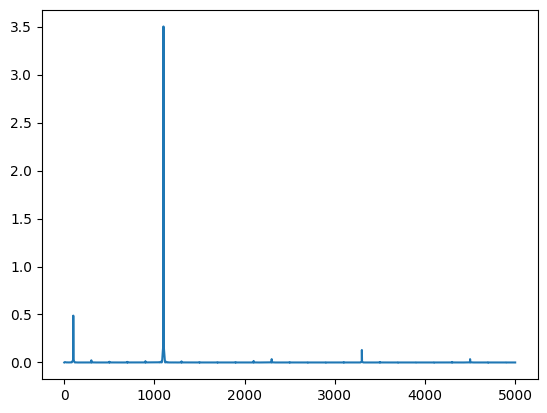

In [94]:
normalize(spectrum)
spectrum.plot()
wave = spectrum.make_wave() # new
wave.make_audio()

## Пилообразный сигнал

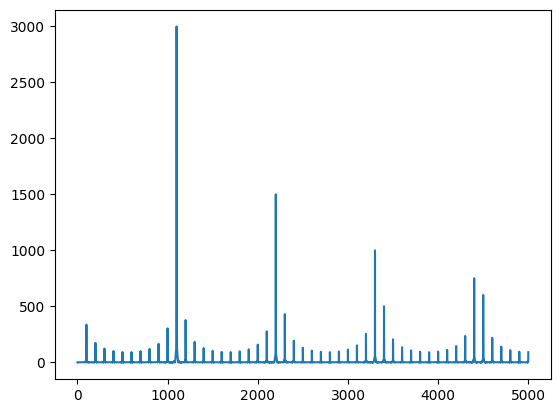

In [95]:
from thinkdsp import SawtoothSignal

signal = SawtoothSignal(freq=1100)
wave = signal.make_wave(framerate=10000, duration=1)
wave.apodize()
spectrum = wave.make_spectrum()
spectrum.plot()
wave.make_audio() # old

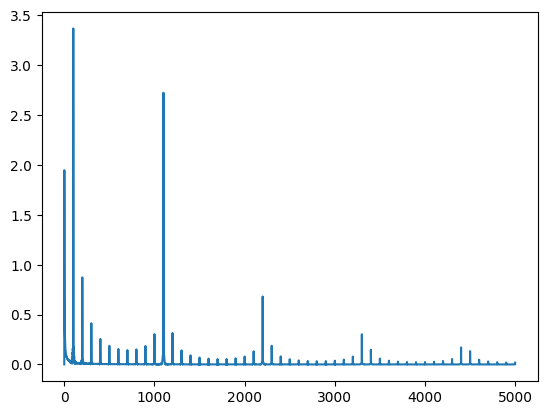

In [96]:
normalize(spectrum)
spectrum.plot()
wave = spectrum.make_wave() # new
wave.make_audio()

Чем больше сигнал, тем сильнее мы уменьшаем его амплитуду, создается эффект звука под водой, основная гармоника смещается ниже.

#  Упражнение 2.6

1. Попробуем сложить синусоиды с нужной амплитудой и частотой

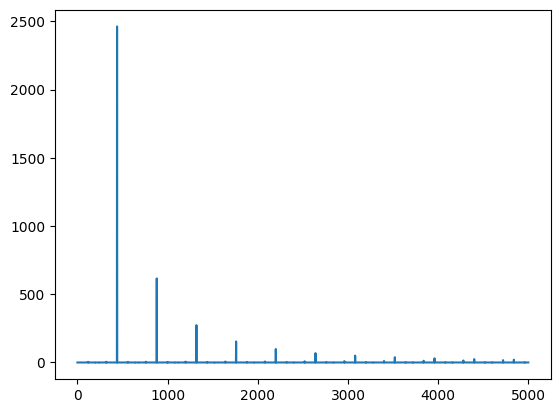

In [ ]:
import numpy as np
from thinkdsp import SinSignal

f0 = 440
framerate = 10000
duration = 0.5
N = 50          # сколько гармоник
C = 1.0

wave = 0
for n in range(1, N+1):
    amp = C / (n**2)
    sig = SinSignal(freq=n*f0, amp=amp)
    w = sig.make_wave(duration=duration, framerate=framerate)
    wave = w if n == 1 else wave + w

wave.normalize()
wave.make_spectrum().plot()

In [111]:
wave.make_audio()

2. Возьмем за основу пилообразный сигнал, и разделим гармоники на `n`

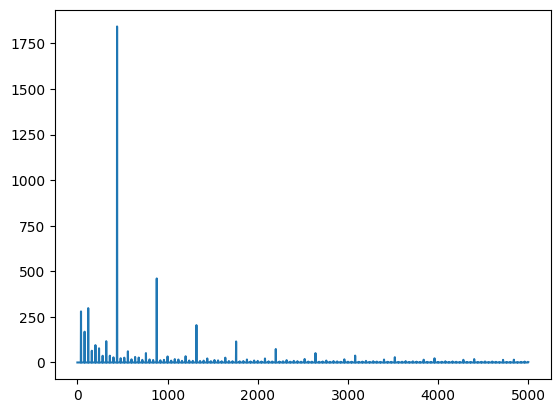

In [ ]:
import numpy as np
from thinkdsp import SawtoothSignal

f0 = 440
framerate = 10000
duration = 0.5

wave = SawtoothSignal(freq=f0).make_wave(duration=duration, framerate=framerate)
spec = wave.make_spectrum()

# модификация: спад 1/f^2 вместо 1/f
for k, f in enumerate(spec.fs):
    if f == 0:
        continue
    spec.hs[k] *= (f0 / f)   # ещё один множитель 1/f

wave2 = spec.make_wave()
wave2.normalize()

wave2.make_spectrum().plot()


In [113]:
wave2.make_audio()